In [1]:
from selfmixed_model import *
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
dataloader = generate_training_data(nx=2048, nt=512)

In [10]:
Y, X, _ = next(iter(dataloader))
y = Y[:, :, 1024:, 256:]
x = X[:, :, 1024:, 256:]
np.save("noisy_signal", y)
np.save("clean_signal", x)
print(y.shape)

torch.Size([1, 1, 1024, 256])


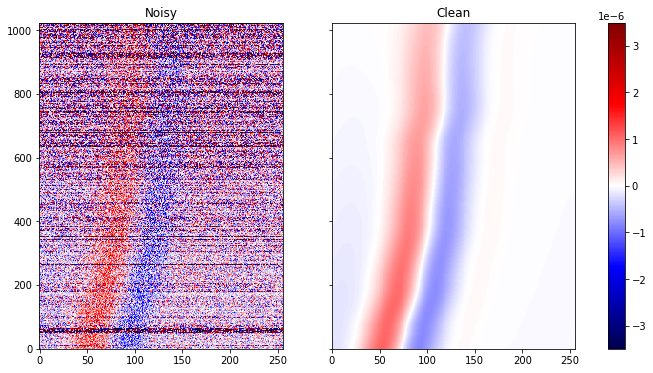

In [11]:
for i in range(y.shape[0]):
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
    v = np.percentile(np.abs(y.numpy()), 95)
    axs[0].imshow(y[i].squeeze().numpy(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)
    im = axs[1].imshow(x[i].squeeze().numpy(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)
    axs[0].set_title('Noisy')
    axs[1].set_title('Clean')

    fig.colorbar(im, ax=axs.ravel().tolist())
    plt.show()

In [13]:
y = np.load("noisy_signal.npy")
print(y.shape)
x = np.load("clean_signal.npy")
print(x.shape)

(1, 1, 1024, 256)
(1, 1, 1024, 256)


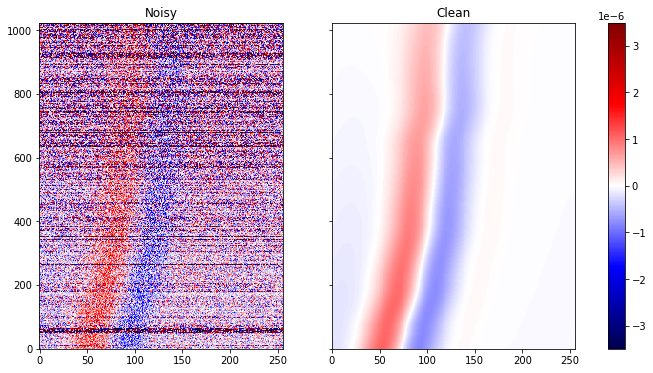

In [15]:
for i in range(y.shape[0]):
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
    v = np.percentile(np.abs(y), 95)
    axs[0].imshow(y[i].squeeze(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)
    im = axs[1].imshow(x[i].squeeze(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)
    axs[0].set_title('Noisy')
    axs[1].set_title('Clean')

    fig.colorbar(im, ax=axs.ravel().tolist())
    plt.show()